In [5]:
# Installing and importing libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller

### **Step 1:** Loading the Dataset

In [6]:
df = pd.read_csv('/content/stock_data.csv', parse_dates= True, index_col="Date")
df.head()

,Unnamed: 0,Open,High,Low,Close,Volume,Name
Date,,,,,,,
2006-01-03,NaN,39.69,41.22,38.79,40.91,24232729,AABA
2006-01-04,NaN,41.22,41.90,40.77,40.97,20553479,AABA
2006-01-05,NaN,40.93,41.73,40.85,41.53,12829610,AABA
2006-01-06,NaN,42.88,43.57,42.80,43.21,29422828,AABA
2006-01-09,NaN,43.10,43.66,42.82,43.42,16268338,AABA


### **Step 3:** Cleaning the Data

In [7]:
# dropping column which is not required for the analysis
df.drop(columns="Unnamed: 0", inplace=True)
df.head()

,Open,High,Low,Close,Volume,Name
Date,,,,,,
2006-01-03,39.69,41.22,38.79,40.91,24232729,AABA
2006-01-04,41.22,41.90,40.77,40.97,20553479,AABA
2006-01-05,40.93,41.73,40.85,41.53,12829610,AABA
2006-01-06,42.88,43.57,42.80,43.21,29422828,AABA
2006-01-09,43.10,43.66,42.82,43.42,16268338,AABA


### **Step 4:** Plotting High Prices Stocks

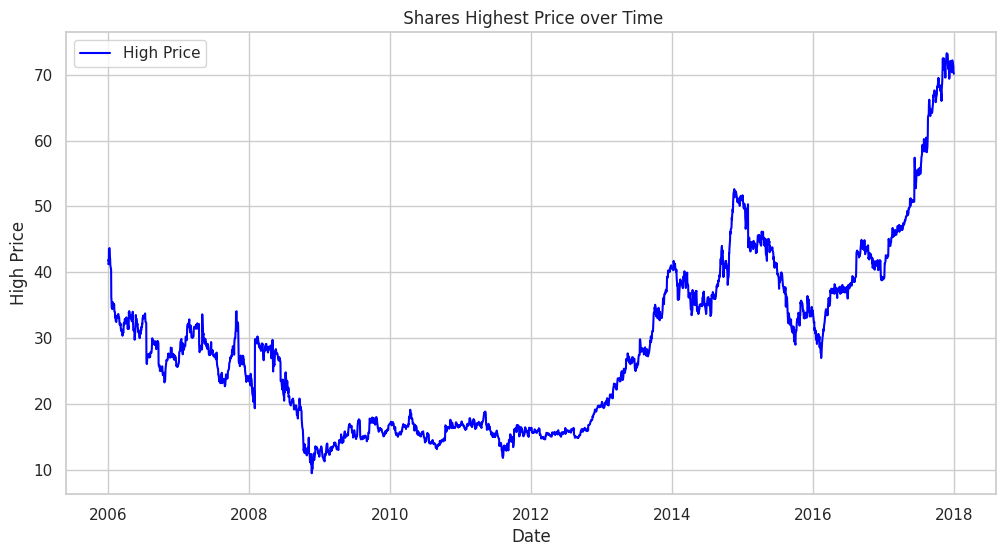

In [8]:
# Since the volume column is of continous data type so we need line graph for visualization
from ipywidgets import Label
sns.set(style = "whitegrid")
plt.figure(figsize=(12,6))

sns.lineplot(data=df, x='Date',y='High',label="High Price", color="blue")
plt.xlabel("Date")
plt.ylabel("High Price")
plt.title(" Shares Highest Price over Time")
plt.show()


### **Step 5:** Resampling Data

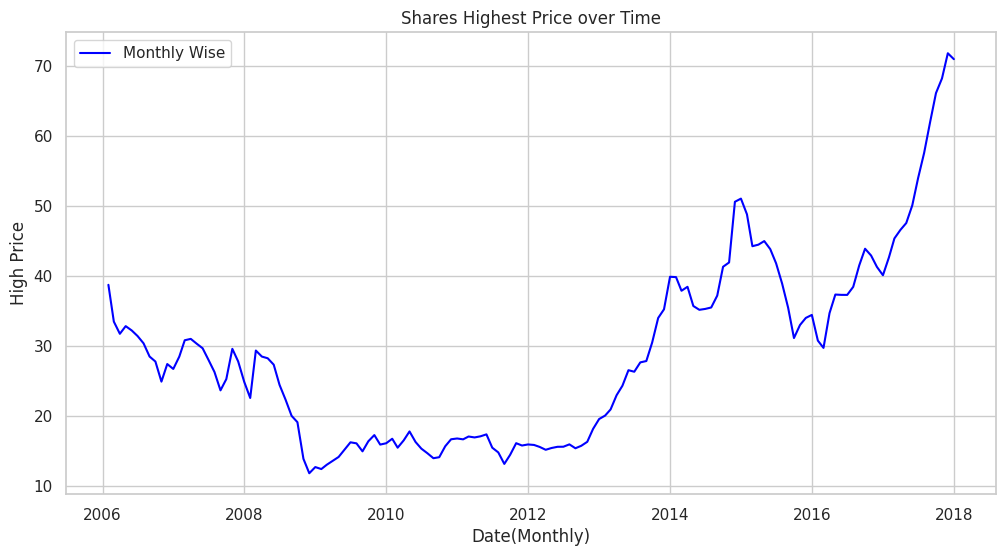

In [10]:
# To understand the trend of the data better, we need resampling method which provide a clearer view of trends and
# patterns when we are dealing with daily data.

df_resampled = df.resample('ME').mean(numeric_only=True)
sns.set(style = "whitegrid")
plt.figure(figsize=(12,6))
sns.lineplot(data=df_resampled,x=df_resampled.index,y='High',label='Monthly Wise',color='blue')
plt.xlabel("Date(Monthly)")
plt.ylabel("High Price")
plt.title("Shares Highest Price over Time")
plt.show()


/tmp/ipykernel_171/893613708.py:1: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  df_resampled_q = df.resample('Q').mean(numeric_only=True)


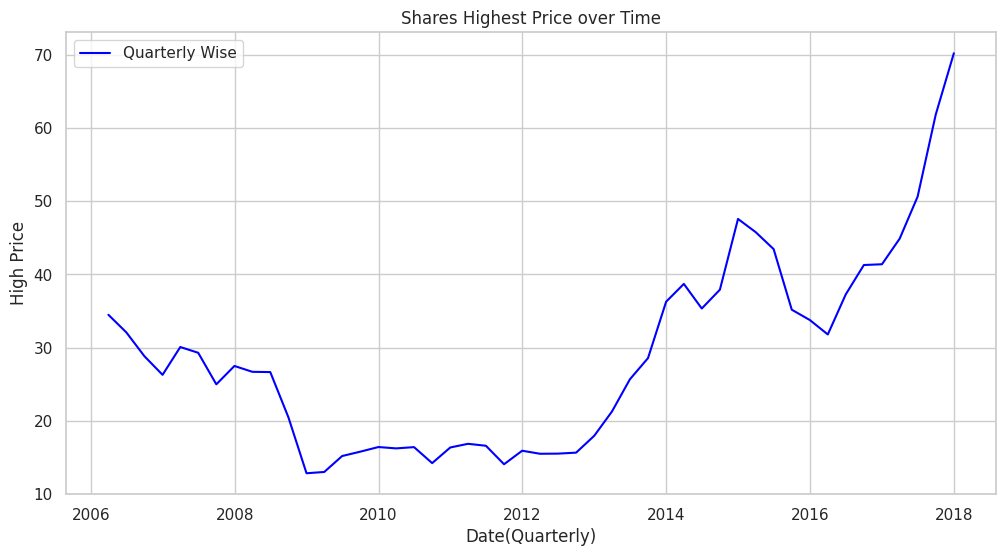

In [ ]:
# Quaterly resampling the data
df_resampled_q = df.resample('Q').mean(numeric_only=True)
sns.set(style = "whitegrid")
plt.figure(figsize=(12,6))
sns.lineplot(data=df_resampled_q,x=df_resampled_q.index,y='High',label='Quarterly Wise',color='blue')
plt.xlabel("Date(Quarterly)")
plt.ylabel("High Price")
plt.title("Shares Highest Price over Time")
plt.show()

### **Step 6:** Detecting Seasonality with Autocorrelation

'Date' is already the index or not present in the DataFrame.


<Figure size 1200x600 with 0 Axes>

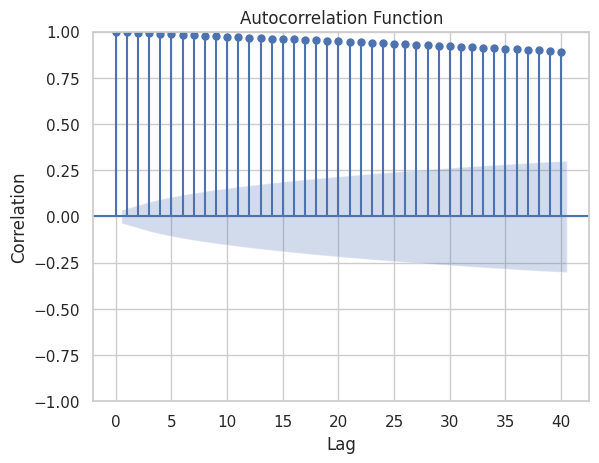

In [ ]:
# Detecting seasonality using Autocorrelation Function (ACF) plot.
if 'Date' not in df.columns:
    print("'Date' is already the index or not present in the DataFrame.")
else:
  df.set_index('Date', inplace=True)

plt.figure(figsize=(12,6))
plot_acf(df['High'], lags=40)
plt.xlabel('Lag')
plt.ylabel('Correlation')
plt.title('Autocorrelation Function')
plt.show()

### **Step 7:** Testing Stationarity with Augmented Dickey-Fuller (ADF) test

In [ ]:
# ADF is a statistical test that is dedicatedly built to test whether univariate time series data is stationary or not.
# This test is based on a hypothesis and can tell us the degree of probability to which it can be accepted.
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['High'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:', result[4])

ADF Statistic: 0.7671404880535936
p-value: 0.9910868050318213
Critical Values: {'1%': np.float64(-3.4325316347197403), '5%': np.float64(-2.862503905260741), '10%': np.float64(-2.5672831121111113)}


The results of the Augmented Dickey-Fuller (ADF) test in simple terms. This test is like asking a question to your data: "Is this data stable over time, or does it have trends or patterns that make it unpredictable?" We call 'stable over time' stationary.

Think of it like this:

Null Hypothesis (H0): The data is not stationary (it has trends or patterns).
Alternative Hypothesis (H1): The data is stationary (it's stable and predictable).
Now, let's look at the numbers you have:

ADF Statistic: 0.7671404880535936

This is the main result of our test. The more negative this number is, the more likely your data is stationary. Numbers closer to zero or positive usually mean the opposite.
p-value: 0.9910868050318213

If the p-value is greater than 0.05, we cannot confidently say our data is stationary (we fail to reject the Null Hypothesis).
In your case, 0.99 is much larger than 0.05.
Critical Values:

'1%': -3.4325...
'5%': -2.8625...
'10%': -2.5672...
These are thresholds.

ADF Statistic (0.76) is a positive number and is much larger than all the negative Critical Values.
Your p-value (0.99) is much larger than 0.05.

**Conclusion:** Both of these indicators point to the same thing: we cannot reject the null hypothesis. In simple words, the test tells us that the original 'High' price series is not stationary. This means it likely has a trend or some other time-dependent structure that makes its statistical properties (like mean and variance) change over time, making it harder to predict directly. That's why we need 'differencing' and 'smoothing' to try and make it stationary!

### **Step 8:** Differencing to Achieve Stationarity

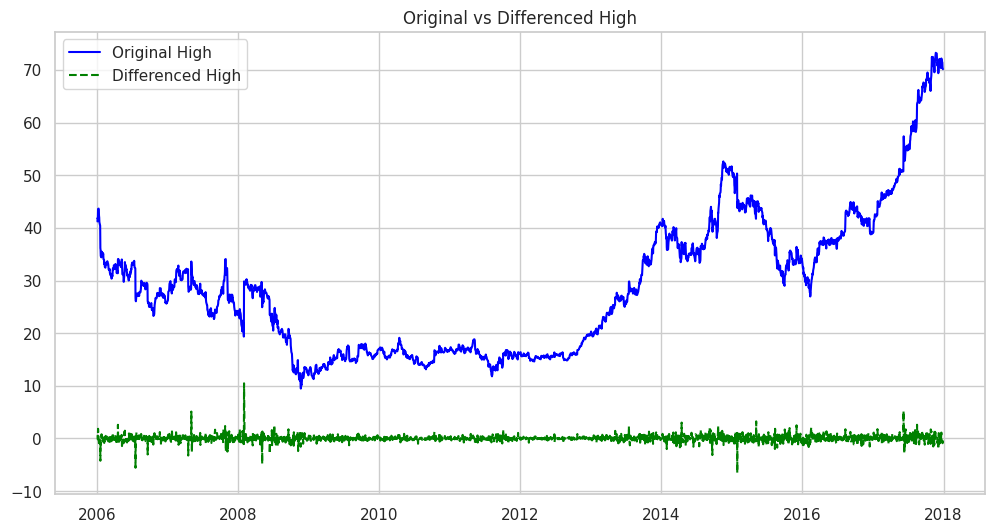

In [ ]:
# Differencing involves subtracting the previous observation from the current observation to remove trends or seasonality.
df['high_diff'] = df['High'].diff()

plt.figure(figsize=(12, 6))
plt.plot(df['High'], label='Original High', color='blue')
plt.plot(df['high_diff'], label='Differenced High', linestyle='--', color='green')
plt.legend()
plt.title('Original vs Differenced High')
plt.show()

### **Step 9:** Smoothing Data with Moving Average

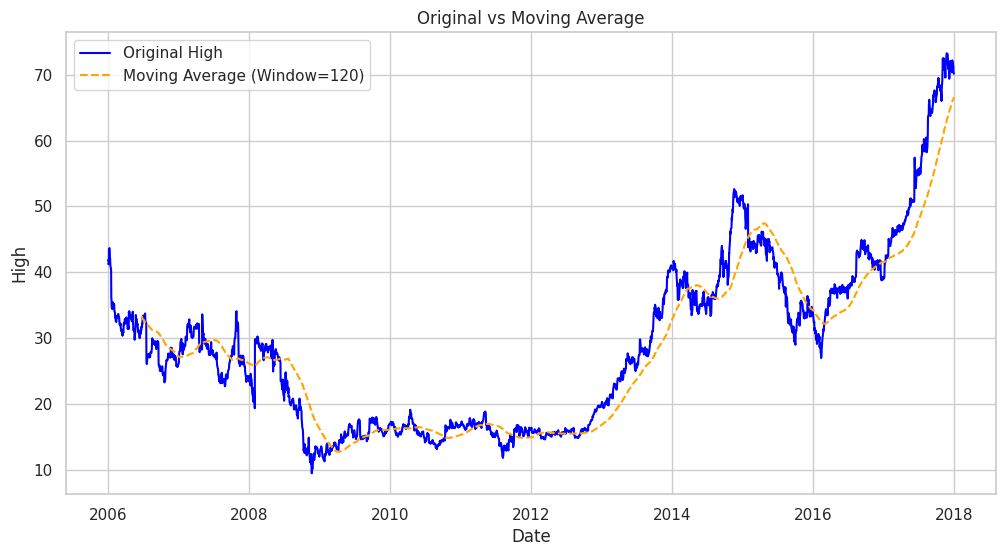

In [ ]:
#df['High'].diff(): helps in calculating the difference between consecutive values in the High column.
# This differencing operation is used to transform a time series into a new series that represents the changes between consecutive observations.
window_size = 120
df['high_smoothed'] = df['High'].rolling(window=window_size).mean()

plt.figure(figsize=(12, 6))

plt.plot(df['High'], label='Original High', color='blue')
plt.plot(df['high_smoothed'], label=f'Moving Average (Window={window_size})', linestyle='--', color='orange')

plt.xlabel('Date')
plt.ylabel('High')
plt.title('Original vs Moving Average')
plt.legend()
plt.show()

**Conclusion:** This calculates the moving average of the High column with a window size of 120(A quarter), creating a smoother curve in the high_smoothed series. The plot compares the original High values with the smoothed version.

### **Step 10:** Original Data Vs Differenced Data

In [ ]:
# Printing the original and differenced data side by side we get:
df_combined = pd.concat([df['High'], df['high_diff']], axis=1)

print(df_combined.head())

             High  high_diff
Date                        
2006-01-03  41.22        NaN
2006-01-04  41.90       0.68
2006-01-05  41.73      -0.17
2006-01-06  43.57       1.84
2006-01-09  43.66       0.09


In [ ]:
# There is a NaN value, we will drop that proceed within our test using dropna
df.dropna(subset=['high_diff'], inplace=True)
df['high_diff'].head()

,high_diff
Date,
2006-01-04,0.68
2006-01-05,-0.17
2006-01-06,1.84
2006-01-09,0.09
2006-01-10,-0.32


In [ ]:
# we conduct the ADF test again t0 check
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['high_diff'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:', result[4])

ADF Statistic: -12.14836747834324
p-value: 1.5912766134149499e-22
Critical Values: {'1%': np.float64(-3.4325316347197403), '5%': np.float64(-2.862503905260741), '10%': np.float64(-2.5672831121111113)}


This is a crucial step after we performed 'differencing' on your data. Let's look at the new results from the ADF test for df['high_diff']:

ADF Statistic: -12.14836747834324
p-value: 1.5912766134149499e-22
Critical Values: (These remain the same as before)
'1%'': -3.4325...
'5%'': -2.8625...
'10%'': -2.5672...
Now, let's interpret these:

ADF Statistic (-12.14):

Notice how this number is now a large negative value. This is a very good sign! It's much smaller (more negative) than all of your critical values.
p-value (1.59e-22):

Since your ADF Statistic (-12.14) is now significantly smaller (more negative) than the critical values, and your p-value (1.59e-22) is much less than 0.05, we can now reject the null hypothesis.

**Conclusion:** This means we have strong evidence to conclude that the high_diff series (the 'High' prices after differencing) is stationary! By subtracting the previous day's 'High' price from the current day's 'High' price, we successfully removed the trends and patterns that made the original series non-stationary. This transformed, stationary series is much more suitable for many time series forecasting models.

